In [ ]:
import os
import torch
import torchvision
from torch.utils.data import random_split, Subset
import torchvision.models as models
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import kagglehub
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from PIL import Image
from pathlib import Path
from sklearn.preprocessing import OneHotEncoder

# Setup and Imports

In [ ]:
# Download latest version
path = kagglehub.dataset_download("itsahmad/indoor-scenes-cvpr-2019")

print("Path to dataset files:", path)

100%|██████████| 2.34G/2.34G [00:33<00:00, 75.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/itsahmad/indoor-scenes-cvpr-2019/versions/1


# Dataset Exploration (EDA)

EDA

In [ ]:
classes = os.listdir(path)
print(classes)

['indoorCVPR_09annotations', 'TrainImages.txt', 'indoorCVPR_09', 'TestImages.txt']


In [ ]:
len(classes)

4

In [ ]:
data_dir = os.path.join(path, 'indoorCVPR_09/Images')
print(f"Data directory set to: {data_dir}")

Data directory set to: /root/.cache/kagglehub/datasets/itsahmad/indoor-scenes-cvpr-2019/versions/1/indoorCVPR_09/Images


# Data Preparation and Augmentation

Transformers

In [ ]:
# add an augmentation for this dataset
from torch.utils.data import ConcatDataset

# Define transformations with augmentation for increased dataset size
augmentation_transforms = transforms.Compose([
    transforms.RandomResizedCrop(256),  # Crop a random part of the image and resize to 256x256
    transforms.RandomHorizontalFlip(),   # Randomly flip the image horizontally
    transforms.RandomRotation(degrees=15),  # Randomly rotate the image by up to 15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),  # Adjust color
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet normalization
])

dataset1 = datasets.ImageFolder(data_dir, transform=augmentation_transforms)
# Create dataset with augmentation
dataset = ConcatDataset([dataset1,
                         datasets.ImageFolder(data_dir, transform=augmentation_transforms),
                         datasets.ImageFolder(data_dir, transform=augmentation_transforms),
                         datasets.ImageFolder(data_dir, transform=augmentation_transforms)])

In [ ]:
dataset_len = len(dataset)
dataset_len

62480

In [ ]:
import random

sample_size = 100
# Ensure sample_size does not exceed dataset_len if the dataset is smaller than 100
sample_size = min(sample_size, dataset_len)

# Get random indices for the sample
random_indices = random.sample(range(dataset_len), sample_size)

sampled_dataset = Subset(dataset, random_indices)
# Assign classes attribute from the original dataset to the sampled dataset
sampled_dataset.classes = dataset1.classes
print(f"Created a sampled dataset with {len(sampled_dataset)} images.")

Created a sampled dataset with 100 images.


### Check for Corrupted Images

In image datasets, the concept of 'missing values' often translates to corrupted or unreadable image files. The following code iterates through the entire concatenated dataset (`dataset`) and attempts to load each image. If any image fails to load or undergo transformations, it indicates a potential issue with that file.

In [ ]:
print('Checking for corrupted images in the dataset...')
corrupted_images_count = 0

for i in range(len(sampled_dataset)):
    try:
        # Attempt to access each item in the dataset
        # This will trigger the image loading and transformation pipeline
        _ = dataset[i]
    except Exception as e:
        corrupted_images_count += 1
        print(f"Found corrupted image at index {i}: {e}")

if corrupted_images_count == 0:
    print("No corrupted images found in the dataset.")
else:
    print(f"Finished checking. Found {corrupted_images_count} corrupted images.")

Checking for corrupted images in the dataset...
No corrupted images found in the dataset.


### Removing Corrupted Images

Based on the previous check, we will now filter out any images that caused loading or transformation errors. We'll create a new dataset containing only the valid images

In [ ]:
print('Filtering out corrupted images and creating a new dataset...')
valid_indices = []
corrupted_images_found = []

for i in range(len(sampled_dataset)):
    try:
        # Attempt to access each item in the dataset to trigger loading and transformations
        _ = dataset[i]
        valid_indices.append(i)
    except Exception as e:
        # Collect indices of corrupted images
        corrupted_images_found.append(i)
        # print(f"Skipping corrupted image at original index {i}: {e}") # Uncomment for detailed logs

if not corrupted_images_found:
    print("No corrupted images were found during the filtering process.")
    cleaned_dataset = sampled_dataset # If no corrupted images, the original dataset is clean
else:
    print(f"Found and removed {len(corrupted_images_found)} corrupted images.")
    print(f"Original dataset size: {len(sampled_dataset)}")
    # Create a new dataset using only the valid indices
    cleaned_dataset = Subset(sampled_dataset, valid_indices)
    print(f"Cleaned dataset size: {len(cleaned_dataset)}")

Filtering out corrupted images and creating a new dataset...
No corrupted images were found during the filtering process.


### Helper Functions for Visualization

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

def show_sample(img, label):
    print("Label:", sampled_dataset.classes[label], "(Class No: "+ str(label) + ")")
    plt.imshow(img.permute(1, 2, 0))

In [ ]:
classes = os.listdir(data_dir)
print(classes)

['videostore', 'lobby', 'concert_hall', 'gameroom', 'trainstation', 'dining_room', 'nursery', 'airport_inside', 'warehouse', 'restaurant', 'kitchen', 'office', 'toystore', 'museum', 'subway', 'tv_studio', 'closet', 'meeting_room', 'grocerystore', 'library', 'florist', 'jewelleryshop', 'children_room', 'classroom', 'casino', 'livingroom', 'bookstore', 'restaurant_kitchen', 'inside_subway', 'bakery', 'gym', 'artstudio', 'greenhouse', 'pantry', 'bar', 'elevator', 'poolinside', 'bedroom', 'laboratorywet', 'operating_room', 'bathroom', 'computerroom', 'winecellar', 'deli', 'garage', 'mall', 'church_inside', 'corridor', 'clothingstore', 'auditorium', 'bowling', 'shoeshop', 'waitingroom', 'hairsalon', 'movietheater', 'prisoncell', 'inside_bus', 'stairscase', 'fastfood_restaurant', 'hospitalroom', 'cloister', 'kindergarden', 'locker_room', 'studiomusic', 'laundromat', 'buffet', 'dentaloffice']


In [ ]:
len(classes)

67

Label: subway (Class No: 59)


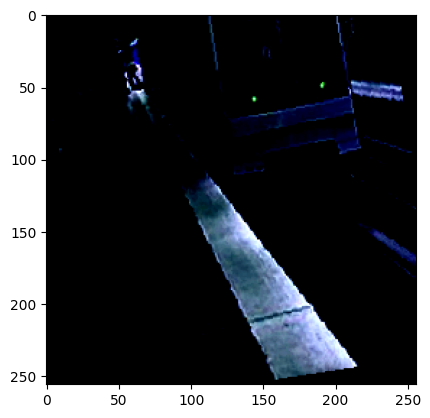

In [ ]:
img, label = sampled_dataset[20]
show_sample(img, label)

# Data Loading and Splitting

In [ ]:
random_seed = 42
torch.manual_seed(random_seed)

In [ ]:
dataset_len = len(sampled_dataset)
dataset_len

100

In [ ]:
train_ds, val_ds, test_ds = random_split(sampled_dataset, [int(dataset_len * 0.7), int(dataset_len * 0.2), int(dataset_len - dataset_len * 0.9)])
len(train_ds), len(val_ds), len(test_ds)

(70, 20, 10)

In [ ]:
def get_labels_from_dataset(sampled_dataset):
    labels = []
    # Assuming dataset is a Subset or wrapped DataLoader
    # If it's a DeviceDataLoader, iterate through it
    if hasattr(sampled_dataset, 'dl'): # Check if it's a DeviceDataLoader
        base_dataset = sampled_dataset.dl.sampled_dataset
    elif hasattr(dataset, 'dataset'): # Check if it's a Subset
        base_dataset = sampled_dataset.sampled_dataset
    else:
        base_dataset = sampled_dataset # Assume it's already a base dataset like ImageFolder

    # If the base dataset is a ConcatDataset, iterate through its constituent datasets
    if isinstance(base_dataset, ConcatDataset):
        for ds in base_dataset.datasets:
            labels.extend([label for _, label in ds])
    elif isinstance(base_dataset, Subset):
        # For Subset, we need to access the original dataset and map indices
        original_dataset = base_dataset.dataset
        for idx in base_dataset.indices:
            _, label = original_dataset[idx]
            labels.append(label)
    else:
        labels = [label for _, label in base_dataset]
    return np.array(labels)

# Get labels from training and validation sets
train_labels_raw = get_labels_from_dataset(train_ds)
val_labels_raw = get_labels_from_dataset(val_ds)

unique_train_classes = np.unique(train_labels_raw)
unique_val_classes = np.unique(val_labels_raw)

print(f"Number of unique classes in the training set: {len(unique_train_classes)}")
print(f"Number of unique classes in the validation set: {len(unique_val_classes)}")

Number of unique classes in the training set: 42
Number of unique classes in the validation set: 16


In [ ]:
# from torch.utils.data.dataloader import DataLoader
batch_size = 10

In [ ]:
train_dl = DataLoader(train_ds, batch_size, shuffle = True, num_workers = 2, pin_memory = True)
val_dl = DataLoader(val_ds, batch_size, num_workers = 2, pin_memory = True)

Using helper function to visualise the batches

In [ ]:
from torchvision.utils import make_grid

def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(make_grid(images, nrow = 16).permute(1, 2, 0))
        break

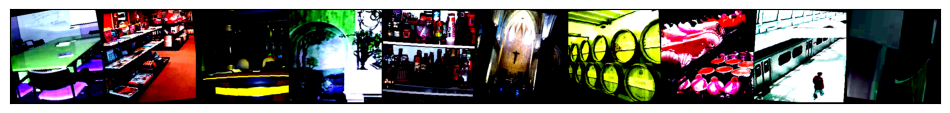

In [ ]:
show_batch(train_dl)

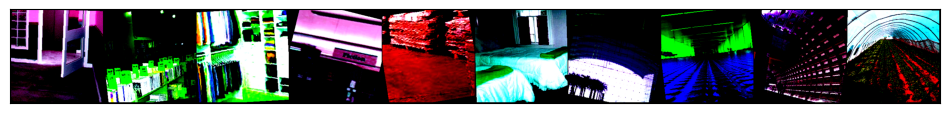

In [ ]:
show_batch(val_dl)

# Model Definition

## Model Base

In [ ]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss

    def validation_step(self, batch):
        images, labels = batch
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss.detach(), 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch {}: train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch+1, result['train_loss'], result['val_loss'], result['val_acc']))

## Using ResNet18

In [ ]:
class ResNet(ImageClassificationBase):
    def __init__(self):
        super().__init__()
        # Use a pretrained model
        self.network = models.resnet18(pretrained=True)
        # Replace last layer
        num_ftrs = self.network.fc.in_features
        self.network.fc = nn.Linear(num_ftrs, len(dataset1.classes))

    def forward(self, xb):
        # Removed sigmoid, as F.cross_entropy expects raw logits
        return self.network(xb)

model = ResNet()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 148MB/s]


# Device Configuration (GPU/CPU)

## Porting to GPU:
GPUs tend to perform faster calculations than CPU. Let's take this advantage and use GPU for computation:

In [ ]:
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

In [ ]:
device = get_default_device()
device

device(type='cpu')

In [ ]:
train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)
to_device(model, device)

ResNet(
  (network): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runn

# Model Training

## Training the Model:
This is the function for fitting the model.

In [ ]:

@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):
    history = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_losses = []
        for batch in tqdm(train_loader):
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        # Validation phase
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        model.epoch_end(epoch, result)
        history.append(result)
    return history

In [ ]:
model = to_device(ResNet(), device)

## Let's start training the model:

In [ ]:
num_epochs = 10
opt_func = torch.optim.Adam
lr = 6e-5

history = fit(num_epochs, lr, model, train_dl, val_dl, opt_func)

  0%|          | 0/7 [00:00<?, ?it/s]

Epoch 1: train_loss: 4.4382, val_loss: 4.3546, val_acc: 0.0000


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch 2: train_loss: 4.0752, val_loss: 4.2568, val_acc: 0.0500


  0%|          | 0/7 [00:00<?, ?it/s]

...

Epoch 8: train_loss: 2.4741, val_loss: 3.7228, val_acc: 0.1500


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch 9: train_loss: 2.3945, val_loss: 3.8112, val_acc: 0.2000


  0%|          | 0/7 [00:00<?, ?it/s]

Epoch 10: train_loss: 2.1686, val_loss: 3.8183, val_acc: 0.1000


In [ ]:
# Save model, optimizer, and loss function
save_path = 'indoor-scene-restnet18-cls'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': opt_func,
    'lr': lr,
    'loss_fn': F.cross_entropy,
}, save_path)

# Model Evaluation and Prediction

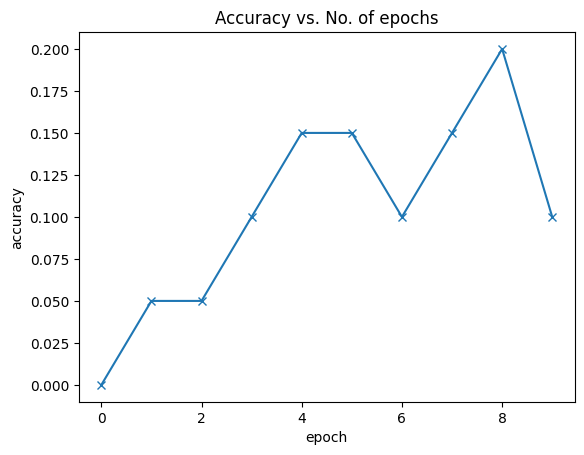

In [ ]:
def plot_accuracies(history):
    accuracies = [x['val_acc'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Accuracy vs. No. of epochs');

plot_accuracies(history)

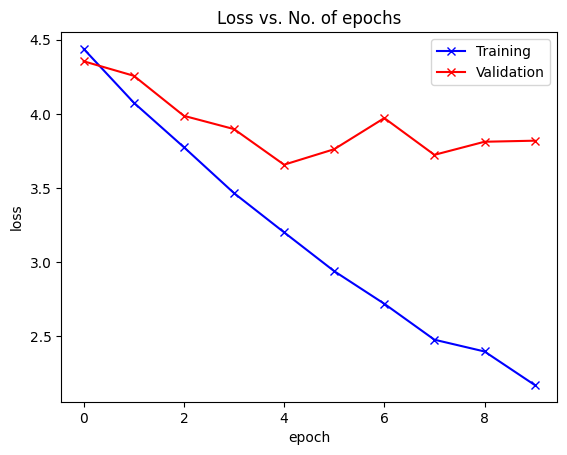

In [ ]:
def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses = [x['val_loss'] for x in history]
    plt.plot(train_losses, '-bx')
    plt.plot(val_losses, '-rx')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Loss vs. No. of epochs');

plot_losses(history)

## Confusion Matrix and Classification Report

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


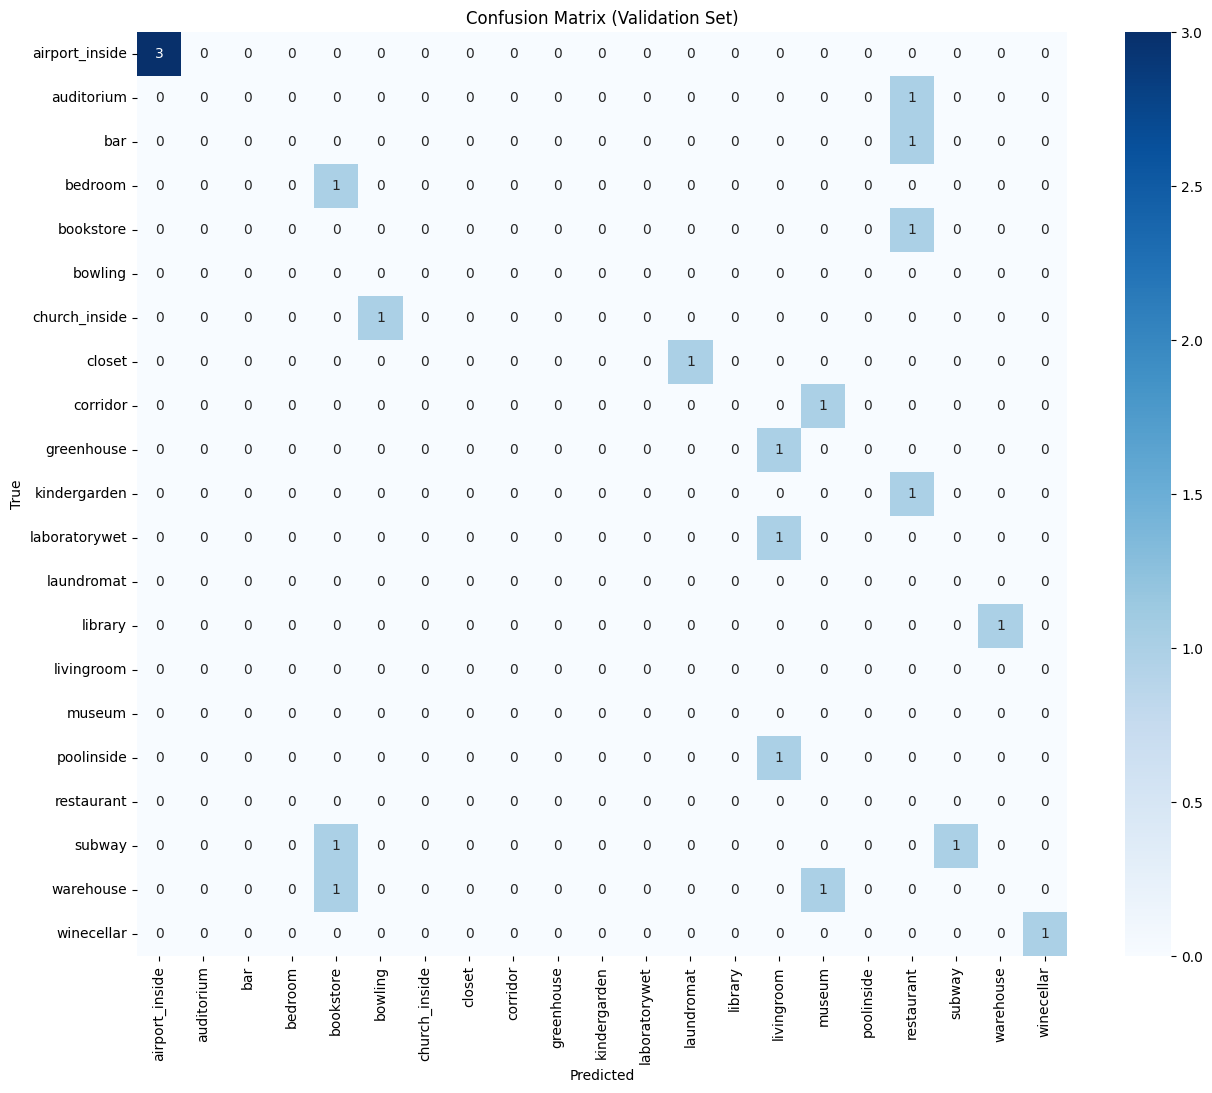


Classification Report (Validation Set):

                precision    recall  f1-score   support

airport_inside       1.00      1.00      1.00         3
    auditorium       0.00      0.00      0.00         1
           bar       0.00      0.00      0.00         1
       bedroom       0.00      0.00      0.00         1
     bookstore       0.00      0.00      0.00         1
       bowling       0.00      0.00      0.00         0
 church_inside       0.00      0.00      0.00         1
        closet       0.00      0.00      0.00         1
      corridor       0.00      0.00      0.00         1
    greenhouse       0.00      0.00      0.00         1
  kindergarden       0.00      0.00      0.00         1
 laboratorywet       0.00      0.00      0.00         1
    laundromat       0.00      0.00      0.00         0
       library       0.00      0.00      0.00         1
    livingroom       0.00      0.00      0.00         0
        museum       0.00      0.00      0.00         0
    p

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [ ]:
# from sklearn.metrics import confusion_matrix, classification_report

@torch.no_grad()
def get_all_predictions(model, loader):
    all_preds = []
    all_labels = []
    all_probs = [] # Added for MSE calculation
    model.eval()
    for images, labels in loader:
        images = to_device(images, device)
        outputs = model(images)
        _, preds = torch.max(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        probs = F.softmax(outputs, dim=1) # Added for MSE calculation
        all_probs.extend(probs.cpu().numpy()) # Added for MSE calculation
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

# Get predictions for the validation set
val_preds, val_labels, val_probs = get_all_predictions(model, val_dl)

# Get all unique labels (both true and predicted) present in the validation set
all_unique_labels = np.union1d(np.unique(val_labels), np.unique(val_preds))
# Filter the class names to only include those that correspond to the unique labels
filtered_target_names = [sampled_dataset.classes[i] for i in all_unique_labels]

# Calculate Confusion Matrix, specifying the labels present
conf_matrix = confusion_matrix(val_labels, val_preds, labels=all_unique_labels)

# Plot Confusion Matrix
plt.figure(figsize=(15, 12))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=filtered_target_names, yticklabels=filtered_target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Validation Set)')
plt.show()

# Print Classification Report
print('\nClassification Report (Validation Set):\n')
print(classification_report(val_labels, val_preds, target_names=filtered_target_names, labels=all_unique_labels))

In [ ]:
evaluate(model, val_dl)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'val_loss': 3.8054182529449463, 'val_acc': 0.15000000596046448}

# Experimenting on test data

In [ ]:
def predict_image(img, model):
    # Convert to a batch of 1
    xb = to_device(img.unsqueeze(0), device)
    # Get predictions from model
    yb = model(xb)
    # Pick index with highest probability
    prob, preds  = torch.max(yb, dim=1)
    # Retrieve the class label
    return sampled_dataset.classes[preds[0].item()]

Label: mall , Predicted: warehouse


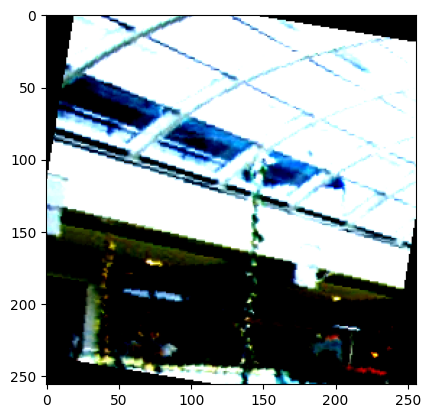

In [ ]:
img, label = test_ds[2]
plt.imshow(img.permute(1, 2, 0))
print('Label:', sampled_dataset.classes[label], ', Predicted:', predict_image(img, model))

Label: artstudio , Predicted: bookstore


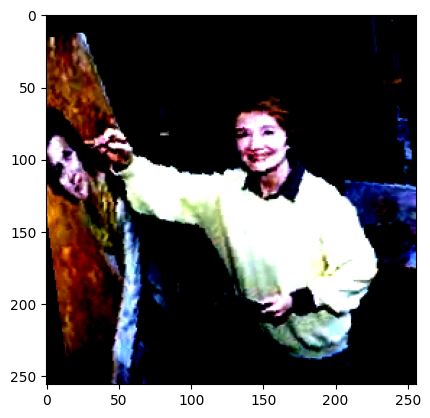

In [ ]:
img, label = test_ds[7]
plt.imshow(img.permute(1, 2, 0))
print('Label:', sampled_dataset.classes[label], ', Predicted:', predict_image(img, model))

Label: pantry , Predicted: pantry


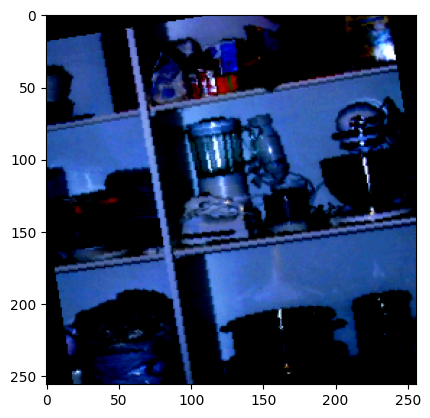

In [ ]:
img, label = test_ds[1]
plt.imshow(img.permute(1, 2, 0))
print('Label:', sampled_dataset.classes[label], ', Predicted:', predict_image(img, model))